In [1]:
"""
Demo script — runs all analysis functions on a single HDF5 file.
Adjust the paths, config, and parameters to match your data.
"""

import numpy as np
import matplotlib.pyplot as plt

from data_loading import load_data
from plotting import (
    plot_diagnostics,
    plot_linearity,
    plot_energy_binned_maps,
    plot_delay_dependence,
)

ModuleNotFoundError: No module named 'data_loading'

In [ ]:
import os
os.getcwd()

In [13]:
# ---------------------------------------------------------------------------
# Parameters — edit these
# ---------------------------------------------------------------------------
FILE_PATH   = "/home/ogalex/glycine/11015651/processed/oga/delay_scan3_120824.h5"
CONFIG      = 1          # 1 or 2
TRIM_START  = 3          # trains to drop from start
TRIM_END    = 11          # trains to drop from end

# Bunch range considered "good" for the delay/energy analysis
BUNCH_START = 5
BUNCH_END   = 40

# TOF ranges for hit counting (ns). Set to None to count all non-zero hits.
E_TOF_RANGE = (500.0, 900.0)   # (tof_min, tof_max) in ns for electrons
I_TOF_RANGE = (1000.0, 5000.0) # (tof_min, tof_max) in ns for ions

# TOF bin edges for spectral analysis (ns)
E_TOF_EDGES = np.linspace(500.0, 900.0, 201)    # 200 bins
I_TOF_EDGES = np.linspace(1000.0, 5000.0, 201)  # 200 bins

# Photon energy bin edges for the 2D maps (eV)
MPE_EDGES = np.linspace(520.0, 560.0, 21)  # 20 bins

# Delay bin edges for the delay-dependence plots
Z_EDGES = np.linspace(-500.0, 500.0, 21)   # 20 bins, units match your stage

# Fixed photon energy range for delay plots (eV)
MPE_RANGE = (535.0, 540.0)

In [14]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
print(f"Loading {FILE_PATH} (config {CONFIG})...")
data = load_data(FILE_PATH, config=CONFIG, trim_start=TRIM_START, trim_end=TRIM_END)
print(f"  Loaded {data.n_trains} trains × {data.n_bunches} bunches/train.")

Loading /home/ogalex/glycine/11015651/processed/oga/delay_scan3_120824.h5 (config 1)...
  Loaded 66798 trains × 400 bunches/train.


Plotting diagnostics...


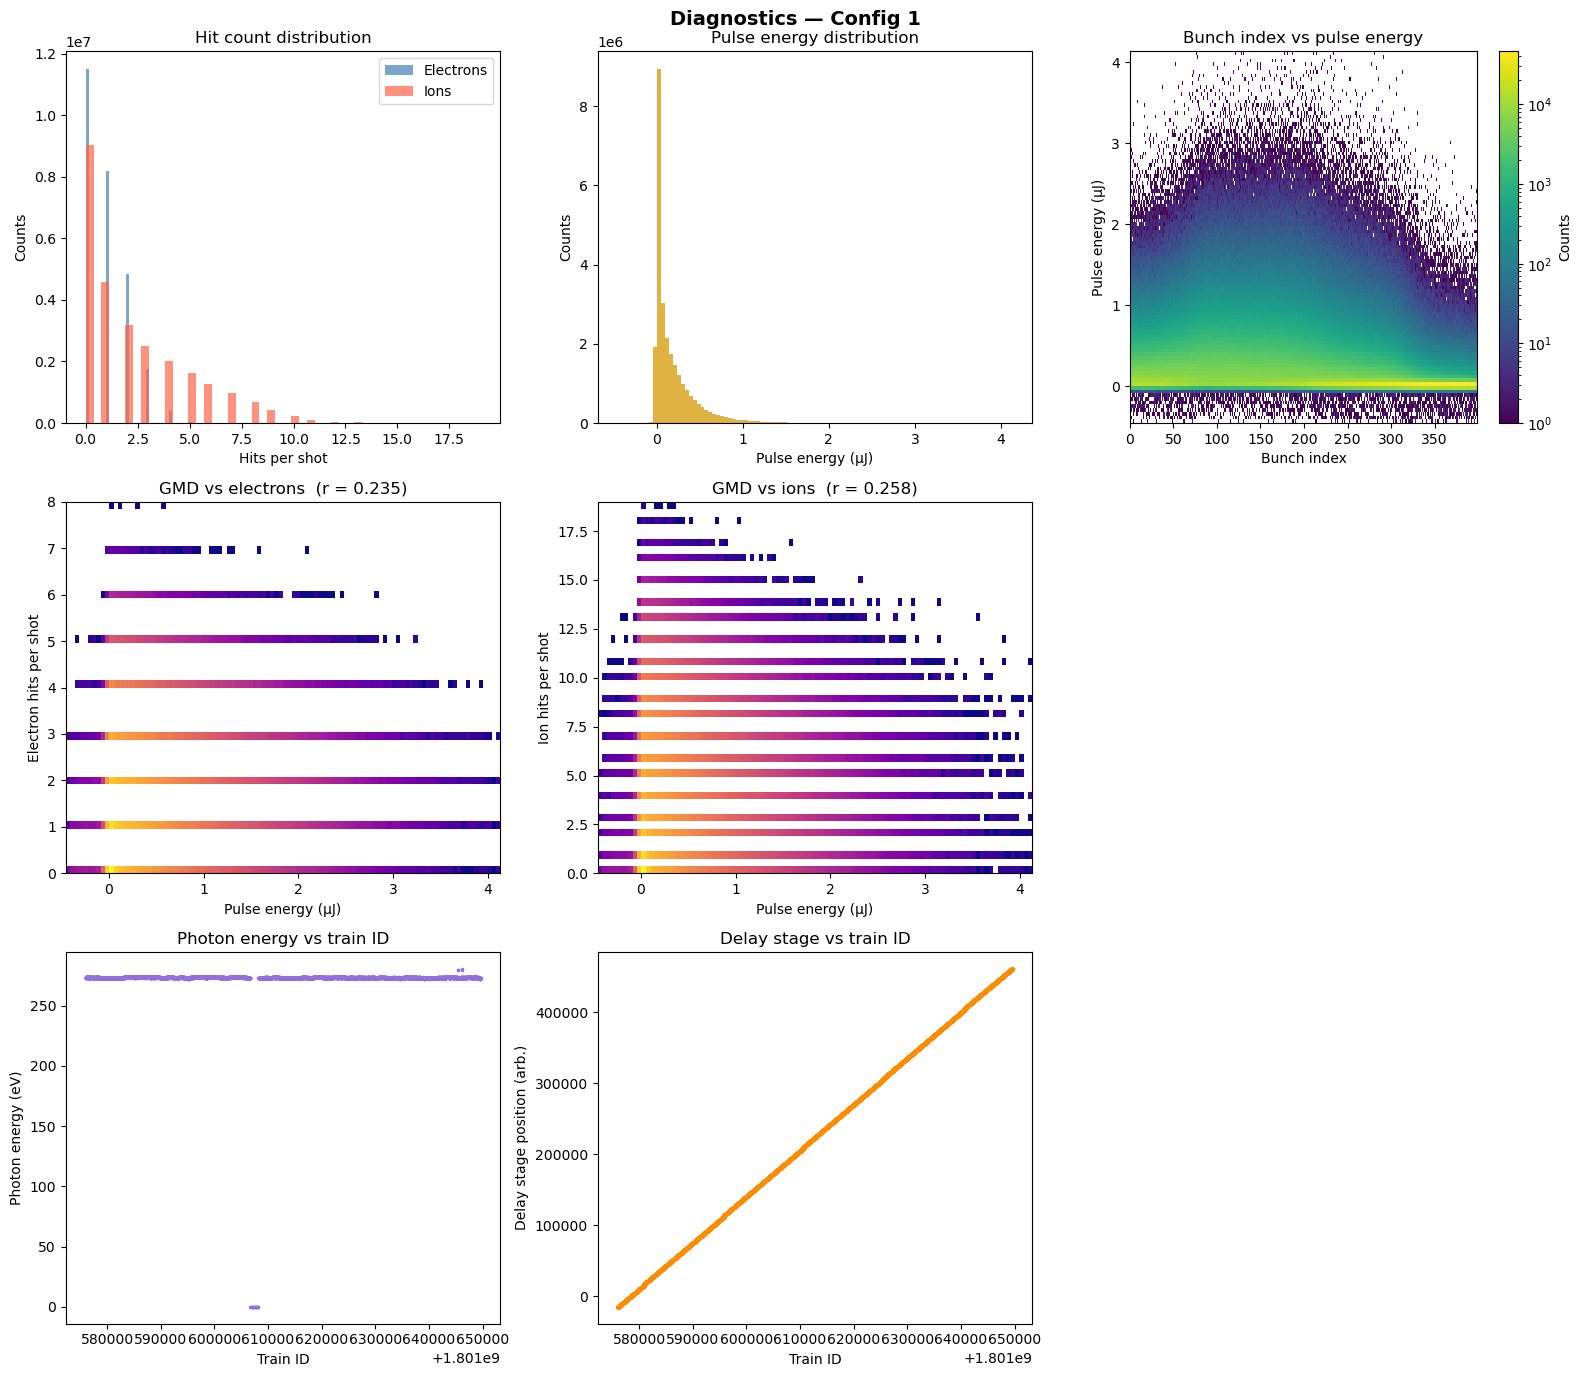

In [15]:
# ---------------------------------------------------------------------------
# 1. Diagnostics
# ---------------------------------------------------------------------------
print("Plotting diagnostics...")
fig_diag, ax_diag = plot_diagnostics(
    data,
    e_tof_range=E_TOF_RANGE,
    i_tof_range=I_TOF_RANGE if CONFIG == 1 else None,
)
# fig_diag.savefig("diagnostics.png", dpi=150)

Plotting linearity...


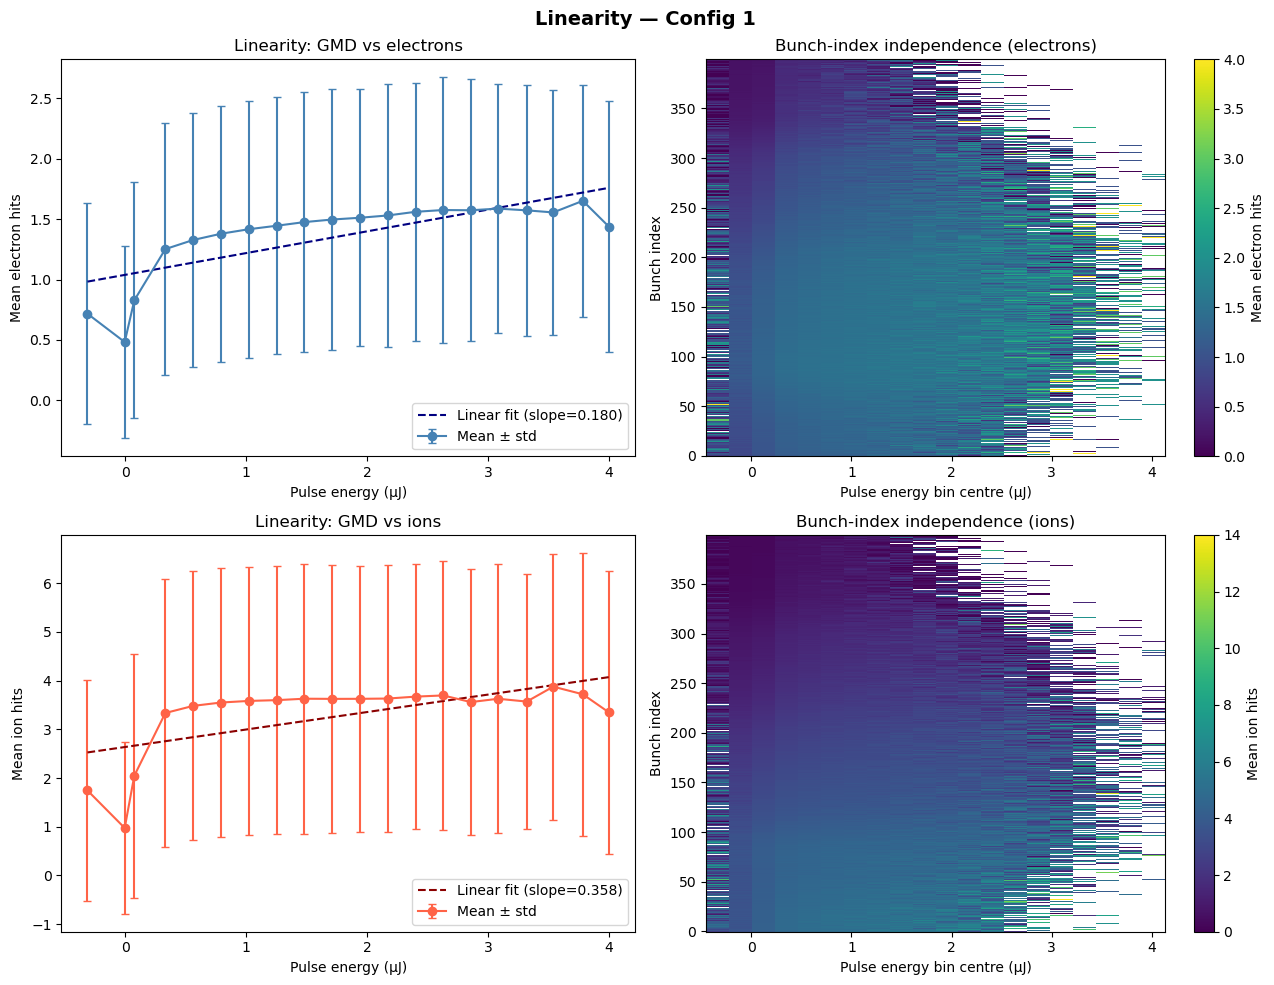

In [16]:
# ---------------------------------------------------------------------------
# 2. Linearity
# ---------------------------------------------------------------------------
print("Plotting linearity...")
fig_lin, ax_lin = plot_linearity(
    data,
    n_gmd_bins=20,
    e_tof_range=E_TOF_RANGE,
    i_tof_range=I_TOF_RANGE if CONFIG == 1 else None,
)
# fig_lin.savefig("linearity.png", dpi=150)

Plotting energy-binned maps...


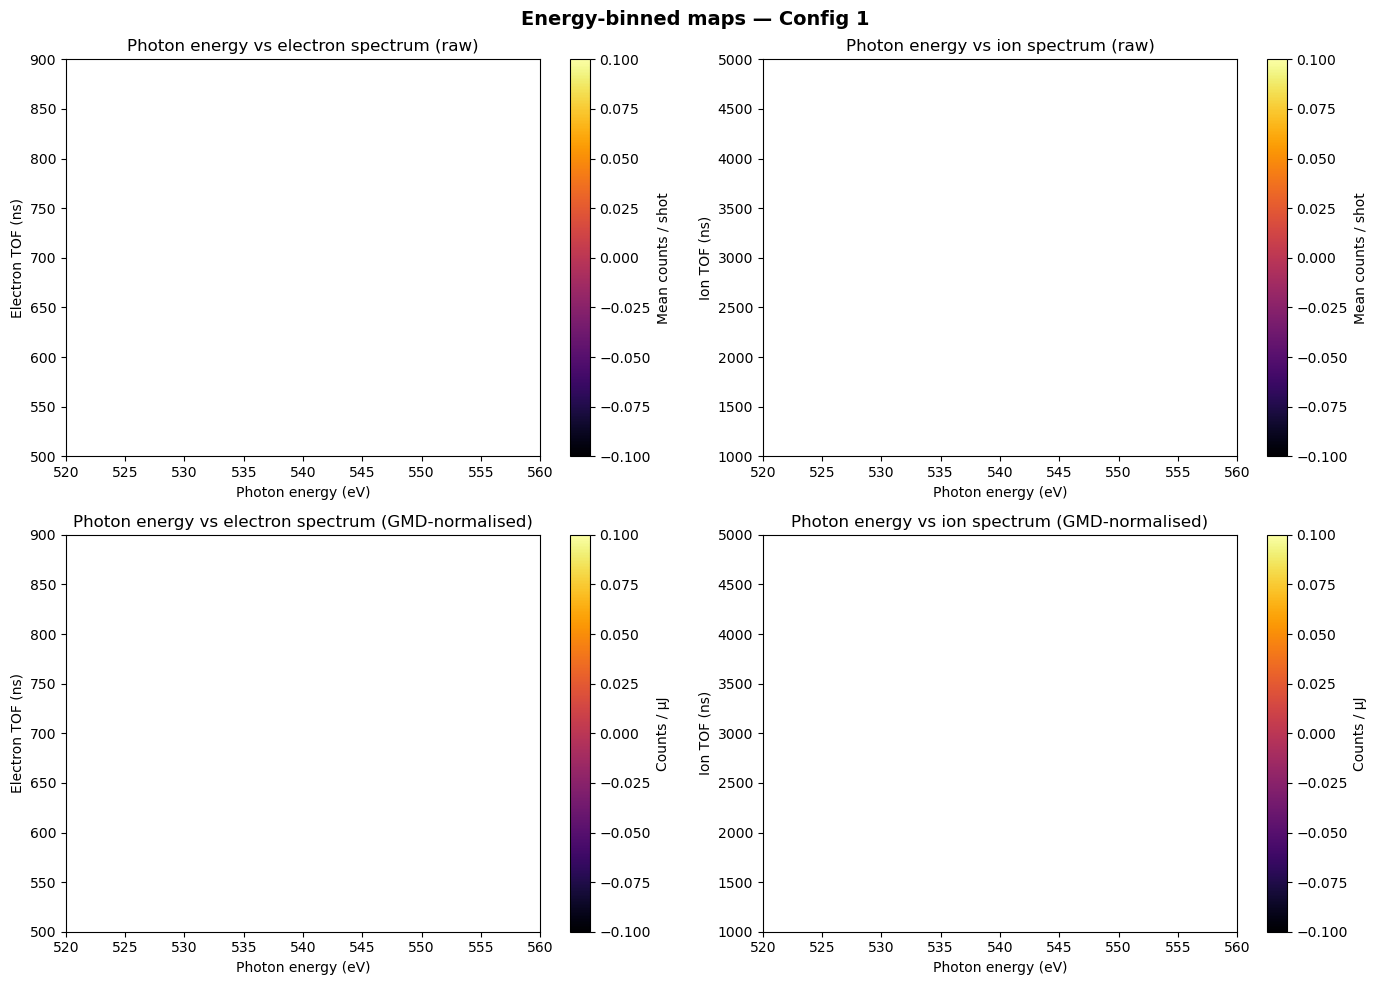

In [17]:
# ---------------------------------------------------------------------------
# 3. Energy-binned 2D maps
# ---------------------------------------------------------------------------
print("Plotting energy-binned maps...")
fig_maps, ax_maps = plot_energy_binned_maps(
    data,
    mpe_edges=MPE_EDGES,
    e_tof_edges=E_TOF_EDGES,
    i_tof_edges=I_TOF_EDGES if CONFIG == 1 else None,
    bunch_start=BUNCH_START,
    bunch_end=BUNCH_END,
)
# fig_maps.savefig("energy_maps.png", dpi=150)

Plotting delay dependence...


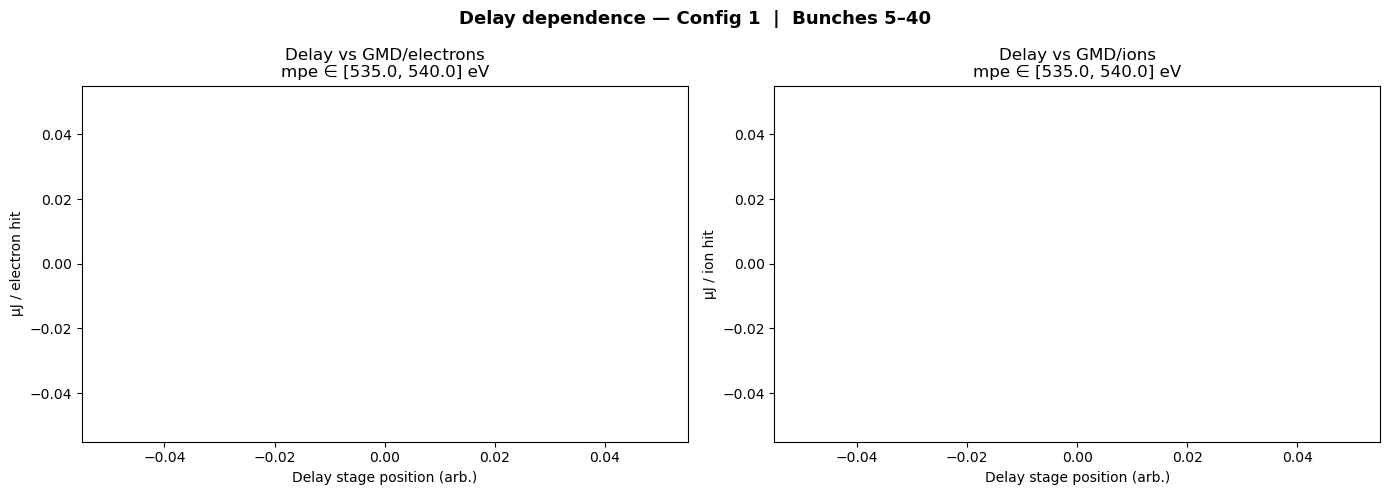

Done.


In [18]:
# ---------------------------------------------------------------------------
# 4. Delay dependence
# ---------------------------------------------------------------------------
print("Plotting delay dependence...")
fig_delay, ax_delay = plot_delay_dependence(
    data,
    mpe_range=MPE_RANGE,
    z_edges=Z_EDGES,
    bunch_start=BUNCH_START,
    bunch_end=BUNCH_END,
    e_tof_range=E_TOF_RANGE,
    i_tof_range=I_TOF_RANGE if CONFIG == 1 else None,
)
# fig_delay.savefig("delay_dependence.png", dpi=150)

plt.show()